<a href="https://colab.research.google.com/github/ktripa/DL_Hydrology/blob/main/Class_Execrises_ARIMA_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Author: Kumar Puran Tripathy (Phd, CEWS lab)
# Class: Hydroclimatic Extremes
# Instructor: Ashok Kumar Mishra
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║         ARIMA TIME SERIES ANALYSIS ║
# ║         80/20 Train-Test Split | Candidate Models | Best Model - ARIMA(3,1,0)           ║
# ║          | One-Step Ahead Forecasting | Diagnostics      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─── 0. INSTALL & IMPORT ──────────────────────────────────────────────────────
# You may need to install the following python libraries
# !pip install statsmodels pmdarima openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools   import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model  import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy                        import stats

# ─── GLOBAL STYLE ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#475569',
    'axes.labelcolor':  '#e2e8f0',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#e2e8f0',
    'grid.color':       '#334155',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'monospace',
    'axes.titlesize':   11,
    'axes.labelsize':   10,
    'legend.facecolor': '#1e293b',
    'legend.edgecolor': '#475569',
})

AMBER   = '#f59e0b'
GREEN   = '#34d399'
BLUE    = '#60a5fa'
ROSE    = '#f87171'
PURPLE  = '#a78bfa'
SLATE   = '#94a3b8'



In [ ]:
# ── Upload file in to google drive: ─────────────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()   # then select Non_Seasonal_data.xlsx

Saving Non Seasonal data.xlsx to Non Seasonal data (3).xlsx


  SECTION 1: LOAD DATA & 80/20 TRAIN-TEST SPLIT

  Total observations  : 100
  Training set        : Y1  – Y80  (80 points, 80%)
  Test set            : Y81 – Y100  (20 points, 20%)

  Train  → min=83.0  max=175.0  mean=124.80  std=31.03
  Test   → min=121.0  max=228.0  mean=186.20  std=32.44


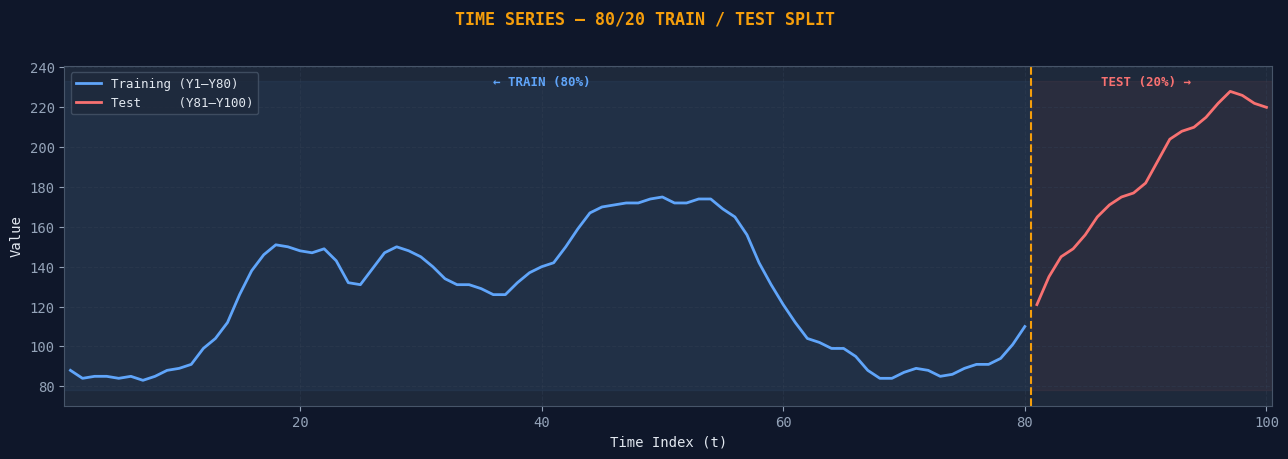

  ✓ Saved: 01_train_test_split.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — LOAD DATA & 80/20 SPLIT
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("  SECTION 1: LOAD DATA & 80/20 TRAIN-TEST SPLIT")
print("=" * 70)

df  = pd.read_excel('Non Seasonal data.xlsx', header=None)
y   = df.iloc[:, 1].values.astype(float)
n   = len(y)                         # 100 observations
t   = np.arange(1, n + 1)

# 80/20 split
TRAIN_SIZE  = 80
train       = y[:TRAIN_SIZE]         # Y1  – Y80
test        = y[TRAIN_SIZE:]         # Y81 – Y100
t_train     = t[:TRAIN_SIZE]
t_test      = t[TRAIN_SIZE:]

print(f"\n  Total observations  : {n}")
print(f"  Training set        : Y1  – Y{TRAIN_SIZE}  ({TRAIN_SIZE} points, {100*TRAIN_SIZE//n}%)")
print(f"  Test set            : Y{TRAIN_SIZE+1} – Y{n}  ({len(test)} points, {100*len(test)//n}%)")
print(f"\n  Train  → min={train.min():.1f}  max={train.max():.1f}  mean={train.mean():.2f}  std={train.std():.2f}")
print(f"  Test   → min={test.min():.1f}  max={test.max():.1f}  mean={test.mean():.2f}  std={test.std():.2f}")

# ── Plot 1: Raw data with train/test split ────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4.5))
fig.suptitle('TIME SERIES — 80/20 TRAIN / TEST SPLIT', fontsize=12,
             color=AMBER, fontweight='bold', y=1.01)
ax.plot(t_train, train, color=BLUE,  lw=2,   label=f'Training (Y1–Y{TRAIN_SIZE})',  zorder=3)
ax.plot(t_test,  test,  color=ROSE,  lw=2,   label=f'Test     (Y{TRAIN_SIZE+1}–Y{n})', zorder=3)
ax.axvline(TRAIN_SIZE + 0.5, color=AMBER, lw=1.5, ls='--', zorder=2)
ax.fill_betweenx([y.min()-5, y.max()+5], 0.5, TRAIN_SIZE+0.5,
                  alpha=0.06, color=BLUE)
ax.fill_betweenx([y.min()-5, y.max()+5], TRAIN_SIZE+0.5, n+0.5,
                  alpha=0.06, color=ROSE)
ax.text(TRAIN_SIZE//2, y.max()+3, '← TRAIN (80%)', ha='center',
        color=BLUE, fontsize=9, fontweight='bold')
ax.text(TRAIN_SIZE + len(test)//2, y.max()+3, 'TEST (20%) →', ha='center',
        color=ROSE, fontsize=9, fontweight='bold')
ax.set_xlabel('Time Index (t)')
ax.set_ylabel('Value')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.4)
ax.set_xlim(0.5, n+0.5)
plt.tight_layout()
plt.savefig('01_train_test_split.png', dpi=150, bbox_inches='tight',
            facecolor='#0f172a')
plt.show()
print("  ✓ Saved: 01_train_test_split.png")




  SECTION 2: ACF & PACF — ORIGINAL SERIES (Training Set)


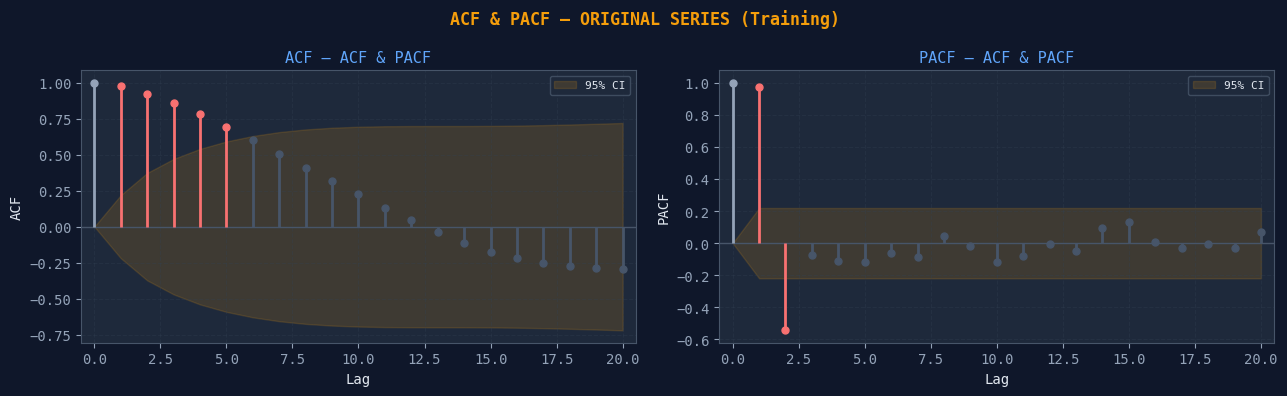

  ✓ Saved: 02_acf_pacf_original.png

  ADF Test — Original Series:
    Statistic : -2.6493
    p-value   : 0.0832  ✗ NON-STATIONARY
    Critical  : 1%=-3.519  5%=-2.900  10%=-2.587


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — ACF / PACF ON ORIGINAL SERIES (TRAINING DATA)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 2: ACF & PACF — ORIGINAL SERIES (Training Set)")
print("=" * 70)

def plot_acf_pacf(series, title, filename, nlags=20, color=BLUE):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=12, color=AMBER, fontweight='bold')

    # Compute manually for custom styling
    acf_vals, acf_ci   = acf(series,  nlags=nlags, alpha=0.05)
    pacf_vals, pacf_ci = pacf(series, nlags=nlags, alpha=0.05, method='ywm')
    lags = np.arange(nlags + 1)

    for ax, vals, ci, label in [
        (axes[0], acf_vals,  acf_ci,  'ACF'),
        (axes[1], pacf_vals, pacf_ci, 'PACF')
    ]:
        ci_lower = ci[:, 0] - vals
        ci_upper = ci[:, 1] - vals

        # Confidence band
        ax.fill_between(lags, ci_lower, ci_upper,
                        alpha=0.15, color=AMBER, label='95% CI')
        ax.axhline(0, color='#475569', lw=1)

        for lag in lags[1:]:
            c = ROSE if abs(vals[lag]) > abs(ci_upper[lag]) else '#475569'
            ax.vlines(lag, 0, vals[lag], colors=c, lw=2)
            ax.plot(lag, vals[lag], 'o', color=c, ms=5, zorder=3)

        ax.vlines(0, 0, vals[0], colors=SLATE, lw=2)
        ax.plot(0, vals[0], 'o', color=SLATE, ms=5)

        ax.set_xlabel('Lag')
        ax.set_ylabel(label)
        ax.set_title(f'{label} — {title.split("—")[0].strip()}', color=color)
        ax.set_xlim(-0.5, nlags + 0.5)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='#0f172a')
    plt.show()
    print(f"  ✓ Saved: {filename}")

plot_acf_pacf(train, 'ACF & PACF — ORIGINAL SERIES (Training)',
              '02_acf_pacf_original.png', color=BLUE)

# ADF Test on original
adf_orig = adfuller(train, autolag='AIC')
print(f"\n  ADF Test — Original Series:")
print(f"    Statistic : {adf_orig[0]:.4f}")
print(f"    p-value   : {adf_orig[1]:.4f}  {'✗ NON-STATIONARY' if adf_orig[1]>0.05 else '✓ STATIONARY'}")
print(f"    Critical  : 1%={adf_orig[4]['1%']:.3f}  5%={adf_orig[4]['5%']:.3f}  10%={adf_orig[4]['10%']:.3f}")





  SECTION 3: FIRST DIFFERENCING & ACF/PACF


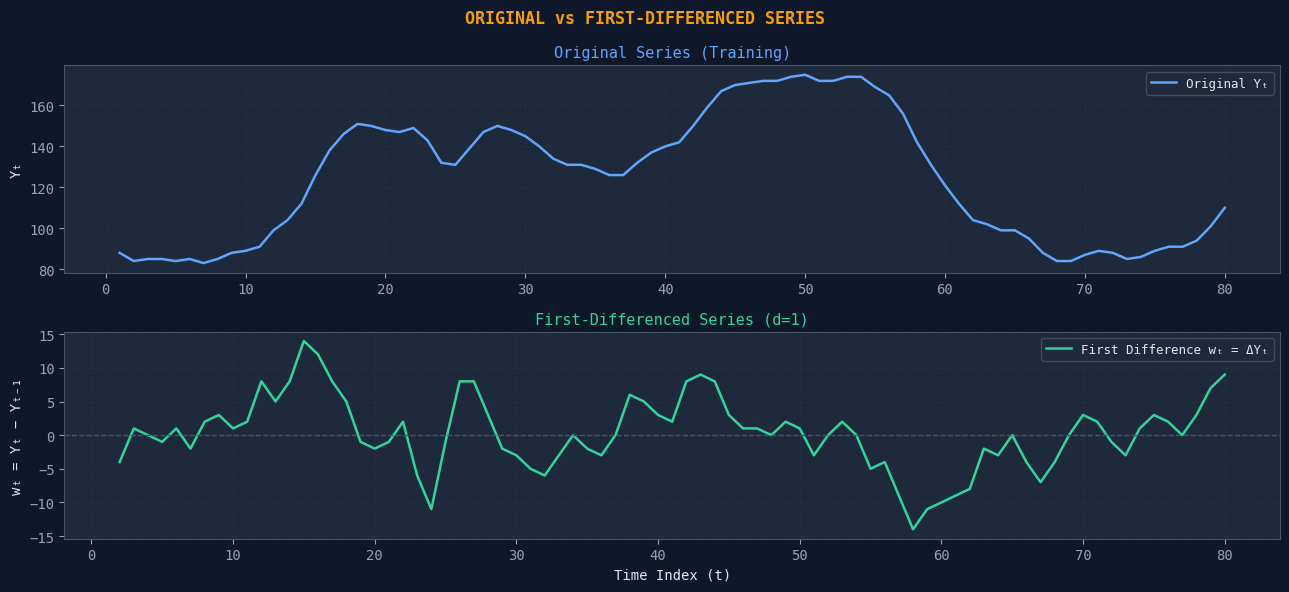

  ✓ Saved: 03_differencing.png


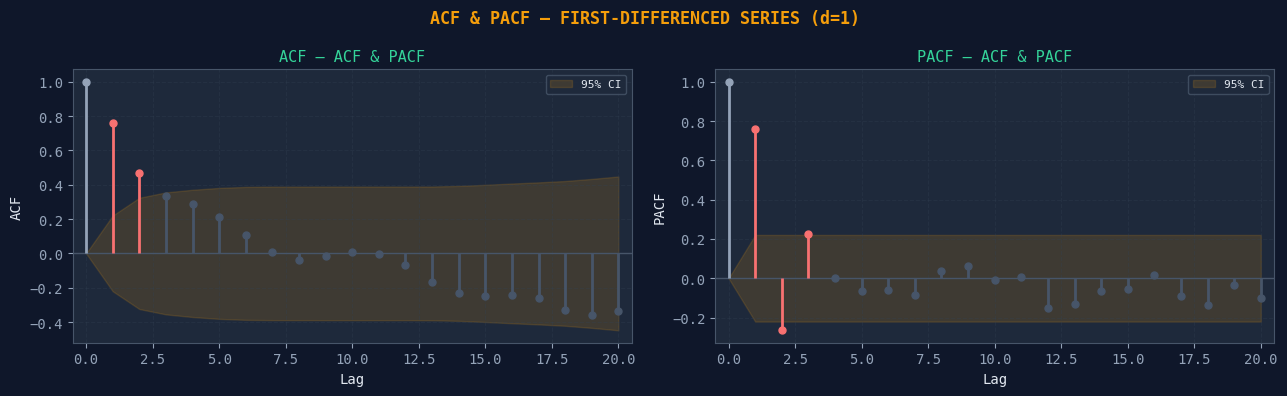

  ✓ Saved: 04_acf_pacf_diff.png

  ADF Test — First-Differenced Series:
    Statistic : -2.5045
    p-value   : 0.1144  ✗ NON-STATIONARY


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — FIRST DIFFERENCING  & ACF/PACF ON DIFF SERIES
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 3: FIRST DIFFERENCING & ACF/PACF")
print("=" * 70)

train_diff = np.diff(train, n=1)   # wt = Yt - Yt-1, length = 79
t_diff     = t_train[1:]

# Plot original vs differenced side-by-side
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=False)
fig.suptitle('ORIGINAL vs FIRST-DIFFERENCED SERIES', fontsize=12,
             color=AMBER, fontweight='bold')

axes[0].plot(t_train, train, color=BLUE, lw=1.8, label='Original Yₜ')
axes[0].set_ylabel('Yₜ')
axes[0].set_title('Original Series (Training)', color=BLUE)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_diff, train_diff, color=GREEN, lw=1.8, label='First Difference wₜ = ΔYₜ')
axes[1].axhline(0, color='#475569', lw=1, ls='--')
axes[1].set_ylabel('wₜ = Yₜ − Yₜ₋₁')
axes[1].set_xlabel('Time Index (t)')
axes[1].set_title('First-Differenced Series (d=1)', color=GREEN)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_differencing.png', dpi=150, bbox_inches='tight',
            facecolor='#0f172a')
plt.show()
print("  ✓ Saved: 03_differencing.png")

# ACF/PACF on differenced series
plot_acf_pacf(train_diff, 'ACF & PACF — FIRST-DIFFERENCED SERIES (d=1)',
              '04_acf_pacf_diff.png', color=GREEN)

# ADF on differenced series
adf_diff = adfuller(train_diff, autolag='AIC')
print(f"\n  ADF Test — First-Differenced Series:")
print(f"    Statistic : {adf_diff[0]:.4f}")
print(f"    p-value   : {adf_diff[1]:.4f}  {'✗ NON-STATIONARY' if adf_diff[1]>0.05 else '✓ STATIONARY'}")




  SECTION 4: CANDIDATE ARIMA MODELS — AIC / BIC COMPARISON

  Model                 AIC        BIC       HQIC     LogLik           σ²
  --------------------------------------------------------------
  ARIMA(1, 1, 0)    421.643    426.381    423.541   -208.821     106.6586
  ARIMA(2, 1, 0)    416.113    423.222    418.961   -205.057     105.7028
  ARIMA(3, 1, 0)    412.560    422.038    416.357   -202.280     104.9858

  ✓ Best model by AIC: ARIMA(3, 1, 0)


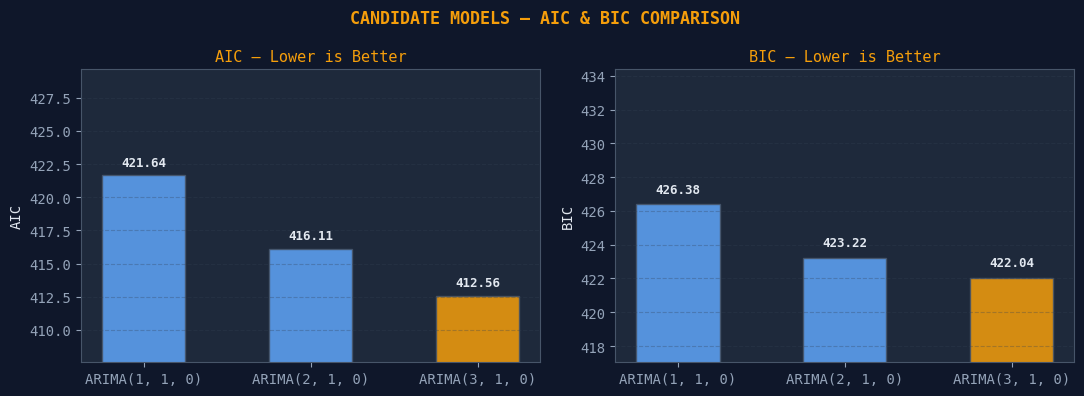

  ✓ Saved: 05_model_comparison.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — CANDIDATE MODELS: FIT & COMPARE
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 4: CANDIDATE ARIMA MODELS — AIC / BIC COMPARISON")
print("=" * 70)

candidate_orders = [(1,1,0), (2,1,0), (3,1,0)]
model_results    = {}

print(f"\n  {'Model':<14} {'AIC':>10} {'BIC':>10} {'HQIC':>10} {'LogLik':>10} {'σ²':>12}")
print("  " + "-" * 62)

for order in candidate_orders:
    mod = ARIMA(train, order=order).fit()
    model_results[order] = mod
    sig2 = np.var(mod.resid)
    print(f"  ARIMA{str(order):<9} {mod.aic:>10.3f} {mod.bic:>10.3f} "
          f"{mod.hqic:>10.3f} {mod.llf:>10.3f} {sig2:>12.4f}")

# Identify best model by AIC
best_order = min(model_results, key=lambda o: model_results[o].aic)
print(f"\n  Best model by AIC: ARIMA{best_order}")

# ── Plot AIC/BIC comparison bar chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('CANDIDATE MODELS — AIC & BIC COMPARISON', fontsize=12,
             color=AMBER, fontweight='bold')

labels = [f'ARIMA{o}' for o in candidate_orders]
aic_vals = [model_results[o].aic for o in candidate_orders]
bic_vals = [model_results[o].bic for o in candidate_orders]
colors   = [AMBER if o == best_order else BLUE for o in candidate_orders]

for ax, vals, metric in [(axes[0], aic_vals, 'AIC'),
                          (axes[1], bic_vals, 'BIC')]:
    bars = ax.bar(labels, vals, color=colors, edgecolor='#475569',
                  width=0.5, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9,
                color='#e2e8f0', fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} — Lower is Better', color=AMBER)
    ax.set_ylim(min(vals) - 5, max(vals) + 8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('05_model_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#0f172a')
plt.show()




In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5 — ARIMA(3,1,0): COEFFICIENTS & FULL EQUATION
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 5: ARIMA(3,1,0) — ESTIMATED COEFFICIENTS & EQUATION")
print("=" * 70)

final_model  = model_results[(3,1,0)]
params       = final_model.params
# params is numpy array: [phi1, phi2, phi3, sigma2]
phi1, phi2, phi3 = params[0], params[1], params[2]
sigma2       = np.var(final_model.resid)

print(f"\n  ── Estimated Coefficients ──────────────────────────────────────")
print(f"    φ₁ (ar.L1) = {phi1:+.6f}")
print(f"    φ₂ (ar.L2) = {phi2:+.6f}")
print(f"    φ₃ (ar.L3) = {phi3:+.6f}")
print(f"    σ²         = {sigma2:.6f}")

print(f"""
  ── FULL EQUATION DERIVATION ─────────────────────────────────────────

  General ARIMA(p,d,q) in backshift notation:
    φ(B) · (1−B)^d · Yₜ = θ(B) · εₜ

  For ARIMA(3,1,0): p=3, d=1, q=0  →  θ(B)=1  (pure AR, no MA term)
    (1 − φ₁B − φ₂B² − φ₃B³) · (1−B) · Yₜ = εₜ

  Step 1 — Define wₜ = (1−B)Yₜ = Yₜ − Yₜ₋₁  (first difference):
    (1 − φ₁B − φ₂B² − φ₃B³) · wₜ = εₜ

  Step 2 — Expand AR polynomial (apply Bᵏwₜ = wₜ₋ₖ):
    wₜ − φ₁wₜ₋₁ − φ₂wₜ₋₂ − φ₃wₜ₋₃ = εₜ

  Step 3 — Rearrange for wₜ:
    wₜ = φ₁wₜ₋₁ + φ₂wₜ₋₂ + φ₃wₜ₋₃ + εₜ

  Step 4 — Back-substitute wₜ = Yₜ − Yₜ₋₁:
    Yₜ − Yₜ₋₁ = φ₁(Yₜ₋₁ − Yₜ₋₂) + φ₂(Yₜ₋₂ − Yₜ₋₃) + φ₃(Yₜ₋₃ − Yₜ₋₄) + εₜ

  Step 5 — Rearrange for Yₜ:
    Yₜ = (1+φ₁)Yₜ₋₁ + (φ₂−φ₁)Yₜ₋₂ + (φ₃−φ₂)Yₜ₋₃ − φ₃Yₜ₋₄ + εₜ

  ── FINAL EQUATION WITH ESTIMATED PARAMETERS ─────────────────────────

    Yₜ = {1+phi1:+.4f}·Yₜ₋₁ + {phi2-phi1:+.4f}·Yₜ₋₂ + {phi3-phi2:+.4f}·Yₜ₋₃ + {-phi3:+.4f}·Yₜ₋₄ + εₜ

  ── FORECASTING EQUATION (εₜ = 0 in expectation) ────────────────────

    Ŷₜ = {1+phi1:+.4f}·Yₜ₋₁ + {phi2-phi1:+.4f}·Yₜ₋₂ + {phi3-phi2:+.4f}·Yₜ₋₃ + {-phi3:+.4f}·Yₜ₋₄

  (equivalently in differenced form):
    ŵₜ = φ₁·wₜ₋₁ + φ₂·wₜ₋₂ + φ₃·wₜ₋₃
       = {phi1:+.4f}·wₜ₋₁ + {phi2:+.4f}·wₜ₋₂ + {phi3:+.4f}·wₜ₋₃
    Ŷₜ = Yₜ₋₁ + ŵₜ
""")




  SECTION 5: ARIMA(3,1,0) — ESTIMATED COEFFICIENTS & EQUATION

  ── Estimated Coefficients ──────────────────────────────────────
    φ₁ (ar.L1) = +1.105699
    φ₂ (ar.L2) = -0.578628
    φ₃ (ar.L3) = +0.264496
    σ²         = 104.985820

  ── FULL EQUATION DERIVATION ─────────────────────────────────────────

  General ARIMA(p,d,q) in backshift notation:
    φ(B) · (1−B)^d · Yₜ = θ(B) · εₜ

  For ARIMA(3,1,0): p=3, d=1, q=0  →  θ(B)=1  (pure AR, no MA term)
    (1 − φ₁B − φ₂B² − φ₃B³) · (1−B) · Yₜ = εₜ

  Step 1 — Define wₜ = (1−B)Yₜ = Yₜ − Yₜ₋₁  (first difference):
    (1 − φ₁B − φ₂B² − φ₃B³) · wₜ = εₜ

  Step 2 — Expand AR polynomial (apply Bᵏwₜ = wₜ₋ₖ):
    wₜ − φ₁wₜ₋₁ − φ₂wₜ₋₂ − φ₃wₜ₋₃ = εₜ

  Step 3 — Rearrange for wₜ:
    wₜ = φ₁wₜ₋₁ + φ₂wₜ₋₂ + φ₃wₜ₋₃ + εₜ

  Step 4 — Back-substitute wₜ = Yₜ − Yₜ₋₁:
    Yₜ − Yₜ₋₁ = φ₁(Yₜ₋₁ − Yₜ₋₂) + φ₂(Yₜ₋₂ − Yₜ₋₃) + φ₃(Yₜ₋₃ − Yₜ₋₄) + εₜ

  Step 5 — Rearrange for Yₜ:
    Yₜ = (1+φ₁)Yₜ₋₁ + (φ₂−φ₁)Yₜ₋₂ + (φ₃−φ₂)Yₜ₋₃ − φ₃Yₜ₋₄ + εₜ

  ── FINAL EQU

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6 — ONE-STEP-AHEAD FORECASTING Y81–Y100
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("  SECTION 6: ONE-STEP-AHEAD FORECASTING Y81–Y100")
print("  (Each Ŷₜ uses ACTUAL observed lags — errors do NOT compound)")
print("=" * 70)
print("""
  ── Strategy: One-Step-Ahead ─────────────────────────────────────────
  For each Ŷₜ we ALWAYS use ACTUAL observed Yₜ₋₁, Yₜ₋₂, Yₜ₋₃, Yₜ₋₄.
  Example:
    Ŷ₈₁ = A·Y₈₀(actual) + B·Y₇₉(actual) + C·Y₇₈(actual) + D·Y₇₇(actual)
    Ŷ₈₂ = A·Y₈₁(actual) + B·Y₈₀(actual) + C·Y₇₉(actual) + D·Y₇₈(actual)
  Each step is independent — prediction errors never feed forward.
""")

a      = 1 + phi1
b      = phi2 - phi1
c      = phi3 - phi2
d_coef = -phi3

print(f"  Coefficients in Yₜ form:")
print(f"    A = (1+φ₁)  = {a:+.6f}")
print(f"    B = (φ₂−φ₁) = {b:+.6f}")
print(f"    C = (φ₃−φ₂) = {c:+.6f}")
print(f"    D = (−φ₃)   = {d_coef:+.6f}")
print(f"\n    Ŷₜ = A·Yₜ₋₁ + B·Yₜ₋₂ + C·Yₜ₋₃ + D·Yₜ₋₄ \n")

forecasts = []

print(f"  {'t':>4}  {'Yₜ₋₁ (act)':>11}  {'Yₜ₋₂ (act)':>11}  "
      f"{'Yₜ₋₃ (act)':>11}  {'Yₜ₋₄ (act)':>11}  "
      f"{'Ŷₜ':>10}  {'Yₜ (obs)':>10}  {'Error':>8}  {'Abs%Err':>8}")
print("  " + "─" * 103)

for step in range(len(test)):
    t_idx = TRAIN_SIZE + step         # 0-based index into full y[]

    # Always use ACTUAL observed values — never a predicted lag
    y_tm1 = y[t_idx - 1]             # Yₜ₋₁  actual
    y_tm2 = y[t_idx - 2]             # Yₜ₋₂  actual
    y_tm3 = y[t_idx - 3]             # Yₜ₋₃  actual
    y_tm4 = y[t_idx - 4]             # Yₜ₋₄  actual

    y_hat    = a*y_tm1 + b*y_tm2 + c*y_tm3 + d_coef*y_tm4
    y_actual = y[t_idx]
    error    = y_actual - y_hat
    abs_pct  = abs(error / y_actual) * 100

    forecasts.append({
        't':         t_idx + 1,
        'Y_tm1':     y_tm1,
        'Y_tm2':     y_tm2,
        'Y_tm3':     y_tm3,
        'Y_tm4':     y_tm4,
        'Y_hat':     round(y_hat, 4),
        'Y_actual':  y_actual,
        'Error':     round(error, 4),
        'AbsPctErr': round(abs_pct, 4),
    })

    print(f"  t={t_idx+1:>3}  {y_tm1:>11.2f}  {y_tm2:>11.2f}  {y_tm3:>11.2f}  {y_tm4:>11.2f}  "
          f"{y_hat:>10.4f}  {y_actual:>10.1f}  {error:>8.4f}  {abs_pct:>7.2f}%")

df_fc = pd.DataFrame(forecasts)

# ── Error metrics ─────────────────────────────────────────────────────────────
rmse = np.sqrt(np.mean(df_fc['Error']**2))
mae  = np.mean(np.abs(df_fc['Error']))
mape = np.mean(df_fc['AbsPctErr'])
bias = np.mean(df_fc['Error'])

print(f"\n  ── One-Step-Ahead Accuracy Metrics (Y81–Y100) ─────────────────")
print(f"    RMSE  = {rmse:.4f}")
print(f"    MAE   = {mae:.4f}")
print(f"    MAPE  = {mape:.4f}%")
print(f"    Bias  = {bias:.4f}  {'(model over-forecasts)' if bias < 0 else '(model under-forecasts)'}")






  SECTION 6: ONE-STEP-AHEAD FORECASTING Y81–Y100
  (Each Ŷₜ uses ACTUAL observed lags — errors do NOT compound)

  ── Strategy: One-Step-Ahead ─────────────────────────────────────────
  For each Ŷₜ we ALWAYS use ACTUAL observed Yₜ₋₁, Yₜ₋₂, Yₜ₋₃, Yₜ₋₄.
  Example:
    Ŷ₈₁ = A·Y₈₀(actual) + B·Y₇₉(actual) + C·Y₇₈(actual) + D·Y₇₇(actual)
    Ŷ₈₂ = A·Y₈₁(actual) + B·Y₈₀(actual) + C·Y₇₉(actual) + D·Y₇₈(actual)
  Each step is independent — prediction errors never feed forward.

  Coefficients in Yₜ form:
    A = (1+φ₁)  = +2.105699
    B = (φ₂−φ₁) = -1.684326
    C = (φ₃−φ₂) = +0.843123
    D = (−φ₃)   = -0.264496

    Ŷₜ = A·Yₜ₋₁ + B·Yₜ₋₂ + C·Yₜ₋₃ + D·Yₜ₋₄  (all ACTUAL observed lags)

     t   Yₜ₋₁ (act)   Yₜ₋₂ (act)   Yₜ₋₃ (act)   Yₜ₋₄ (act)          Ŷₜ    Yₜ (obs)     Error   Abs%Err
  ───────────────────────────────────────────────────────────────────────────────────────────────────────
  t= 81       110.00       101.00        94.00        91.00    116.6944       121.0    4.3056     3.56%


  SECTION 7: OBSERVED vs PREDICTED — FULL PLOT


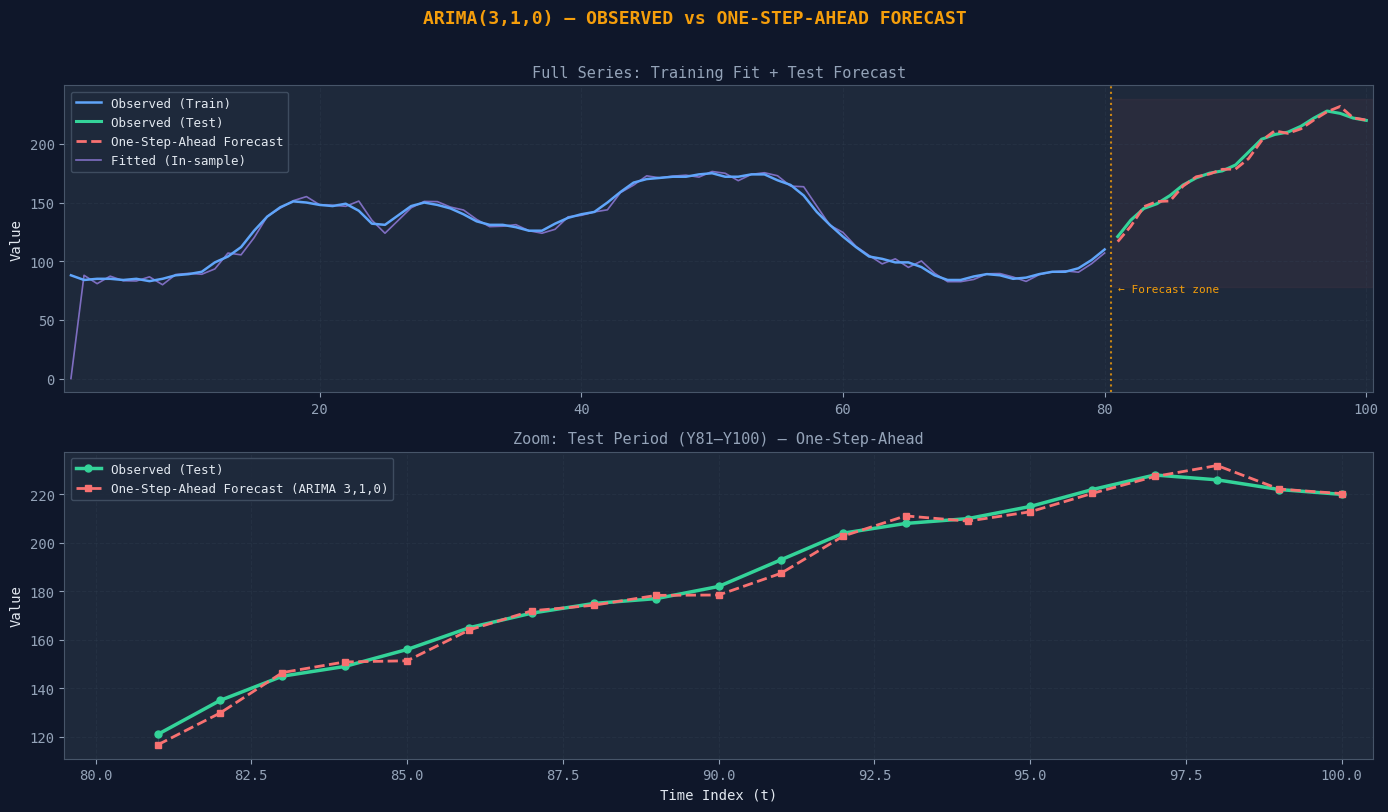

  ✓ Saved: 06_one_step_ahead_forecast.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7 — OBSERVED vs PREDICTED PLOT
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 7: OBSERVED vs PREDICTED — FULL PLOT")
print("=" * 70)

t_all   = np.arange(1, n + 1)
y_all   = y.copy()

# In-sample fitted values from statsmodels
fitted_insample = final_model.fittedvalues   # length = TRAIN_SIZE

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('ARIMA(3,1,0) — OBSERVED vs ONE-STEP-AHEAD FORECAST', fontsize=13,
             color=AMBER, fontweight='bold', y=1.01)

# ── Top panel: full series ────────────────────────────────────────────────────
ax = axes[0]
ax.plot(t_train, train, color=BLUE, lw=1.8, label='Observed (Train)', zorder=3)
ax.plot(t_test,  test,  color=GREEN, lw=2.2, label='Observed (Test)',  zorder=3)
ax.plot(t_test,  df_fc['Y_hat'], color=ROSE, lw=2, ls='--',
        label='One-Step-Ahead Forecast', zorder=4)
ax.plot(t_train, fitted_insample, color=PURPLE, lw=1.2, alpha=0.7,
        label='Fitted (In-sample)', zorder=2)
ax.axvline(TRAIN_SIZE + 0.5, color=AMBER, lw=1.5, ls=':', alpha=0.8)
ax.fill_betweenx([y.min()-5, y.max()+10], TRAIN_SIZE+0.5, n+0.5,
                  alpha=0.05, color=ROSE)
ax.text(TRAIN_SIZE + 1, y.min()-2, '← Forecast zone', color=AMBER,
        fontsize=8, va='top')
ax.set_ylabel('Value')
ax.set_title('Full Series: Training Fit + Test Forecast', color=SLATE)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(0.5, n + 0.5)

# ── Bottom panel: test zone zoom ──────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(t_test, test,          color=GREEN, lw=2.5, marker='o', ms=5,
         label='Observed (Test)', zorder=3)
ax2.plot(t_test, df_fc['Y_hat'], color=ROSE, lw=2,  marker='s', ms=4,
         ls='--', label='One-Step-Ahead Forecast (ARIMA 3,1,0)', zorder=4)
for i, (obs, pred) in enumerate(zip(test, df_fc['Y_hat'])):
    ax2.vlines(t_test[i], min(obs, pred), max(obs, pred),
               color='#475569', lw=0.8, alpha=0.5)
ax2.set_xlabel('Time Index (t)')
ax2.set_ylabel('Value')
ax2.set_title('Zoom: Test Period (Y81–Y100) — One-Step-Ahead', color=SLATE)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(TRAIN_SIZE - 0.5, n + 0.5)

plt.tight_layout()
plt.savefig('06_one_step_ahead_forecast.png', dpi=150, bbox_inches='tight',
            facecolor='#0f172a')
plt.show()
print("  ✓ Saved: 06_one_step_ahead_forecast.png")






  SECTION 8: COMPLETE FORECAST TABLE Y81 – Y100

     t     Ŷₜ (Forecast)   Yₜ (Observed)       Error   Abs Error  Abs% Error
  ────────────────────────────────────────────────────────────────────────
  t= 81          116.6944           121.0      4.3056      4.3056       3.56%
  t= 82          129.8065           135.0      5.1935      5.1935       3.85%
  t= 83          146.4953           145.0     -1.4953      1.4953       1.03%
  t= 84          150.8657           149.0     -1.8657      1.8657       1.25%
  t= 85          151.3395           156.0      4.6605      4.6605       2.99%
  t= 86          164.0703           165.0      0.9297      0.9297       0.56%
  t= 87          171.9589           171.0     -0.9589      0.9589       0.56%
  t= 88          174.2780           175.0      0.7220      0.7220       0.41%
  t= 89          178.3315           177.0     -1.3315      1.3315       0.75%
  t= 90          178.4839           182.0      3.5161      3.5161       1.93%
  t= 91          1

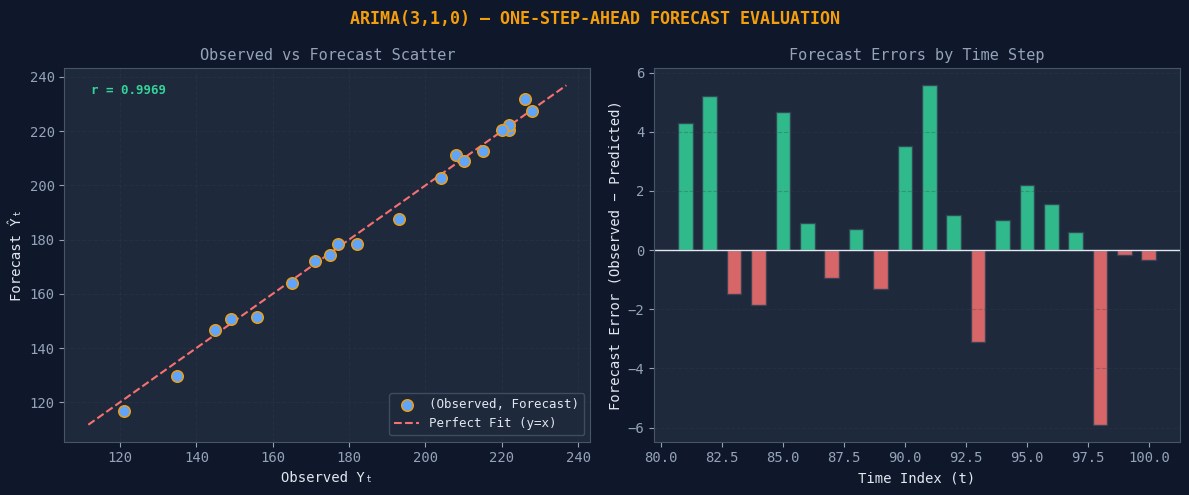

  ✓ Saved: 07_forecast_evaluation_one_step.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 8 — FORECAST TABLE (Y81–Y100)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 8: COMPLETE FORECAST TABLE Y81 – Y100")
print("=" * 70)

print(f"\n  {'t':>4}  {'Ŷₜ (Forecast)':>16}  {'Yₜ (Observed)':>14}  "
      f"{'Error':>10}  {'Abs Error':>10}  {'Abs% Error':>10}")
print("  " + "─" * 72)
for _, row in df_fc.iterrows():
    print(f"  t={int(row.t):>3}  {row.Y_hat:>16.4f}  {row.Y_actual:>14.1f}  "
          f"{row.Error:>10.4f}  {abs(row.Error):>10.4f}  {row.AbsPctErr:>9.2f}%")

print(f"\n  {'':>26} RMSE={rmse:.4f}   MAE={mae:.4f}   MAPE={mape:.2f}%")

# ── Scatter: Observed vs Predicted ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('ARIMA(3,1,0) — ONE-STEP-AHEAD FORECAST EVALUATION', fontsize=12,
             color=AMBER, fontweight='bold')

# Scatter
ax = axes[0]
obs  = df_fc['Y_actual'].values
pred = df_fc['Y_hat'].values
ax.scatter(obs, pred, color=BLUE, edgecolors=AMBER, s=70, zorder=3,
           label='(Observed, Forecast)')
lims = [min(obs.min(), pred.min()) - 5, max(obs.max(), pred.max()) + 5]
ax.plot(lims, lims, color=ROSE, lw=1.5, ls='--', label='Perfect Fit (y=x)')
ax.set_xlabel('Observed Yₜ')
ax.set_ylabel('Forecast Ŷₜ')
ax.set_title('Observed vs Forecast Scatter', color=SLATE)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
# Correlation
r, p = stats.pearsonr(obs, pred)
ax.text(0.05, 0.93, f'r = {r:.4f}', transform=ax.transAxes,
        color=GREEN, fontsize=9, fontweight='bold')

# Forecast errors bar
ax2 = axes[1]
errors = df_fc['Error'].values
colors_bar = [GREEN if e >= 0 else ROSE for e in errors]
ax2.bar(df_fc['t'], errors, color=colors_bar, edgecolor='#334155',
        width=0.6, alpha=0.85)
ax2.axhline(0, color='#e2e8f0', lw=1)
ax2.set_xlabel('Time Index (t)')
ax2.set_ylabel('Forecast Error (Observed − Predicted)')
ax2.set_title('Forecast Errors by Time Step', color=SLATE)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('07_forecast_evaluation_one_step.png', dpi=150, bbox_inches='tight',
            facecolor='#0f172a')
plt.show()
print("  ✓ Saved: 07_forecast_evaluation_one_step.png")




  SECTION 9: DIAGNOSTIC PLOTS — RESIDUAL ANALYSIS


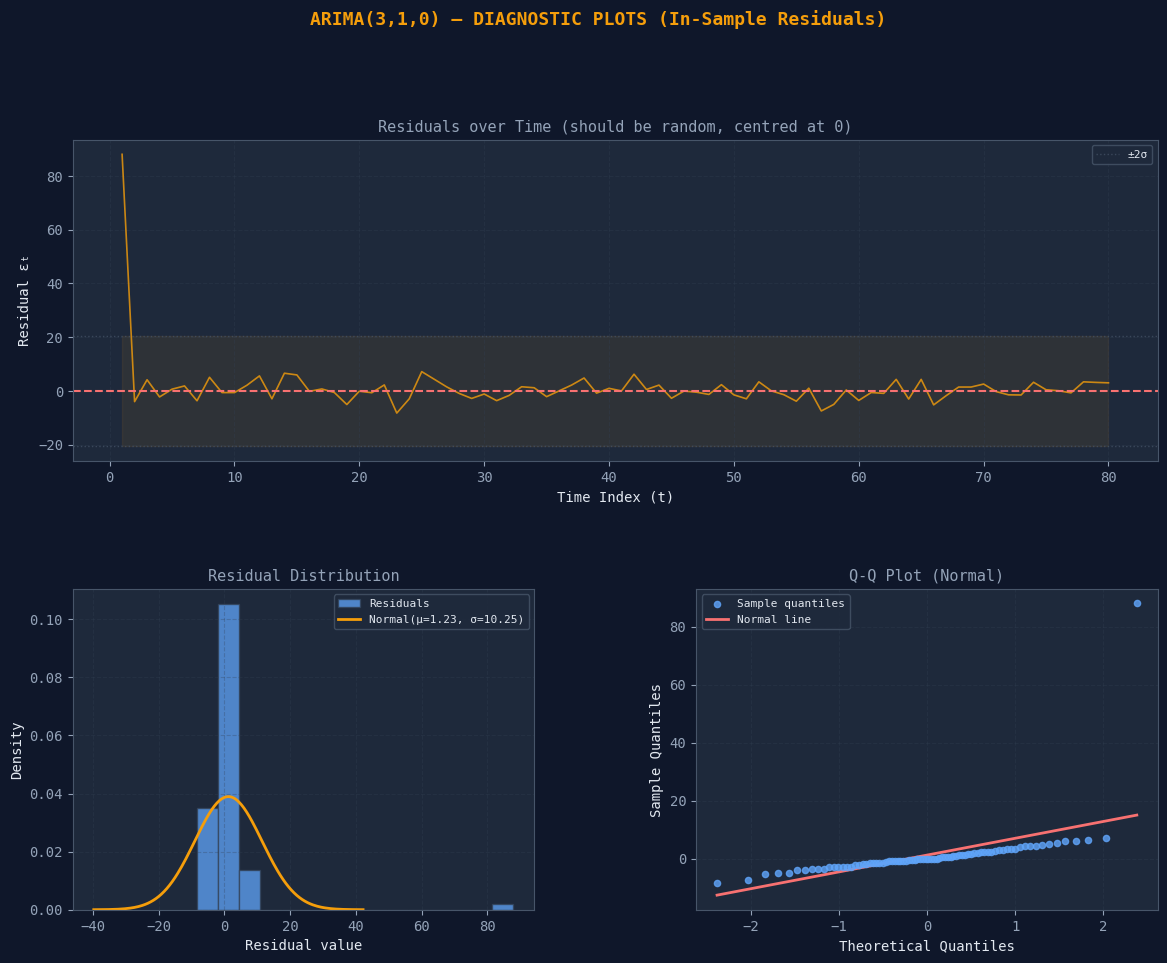

  ✓ Saved: 08_diagnostics.png


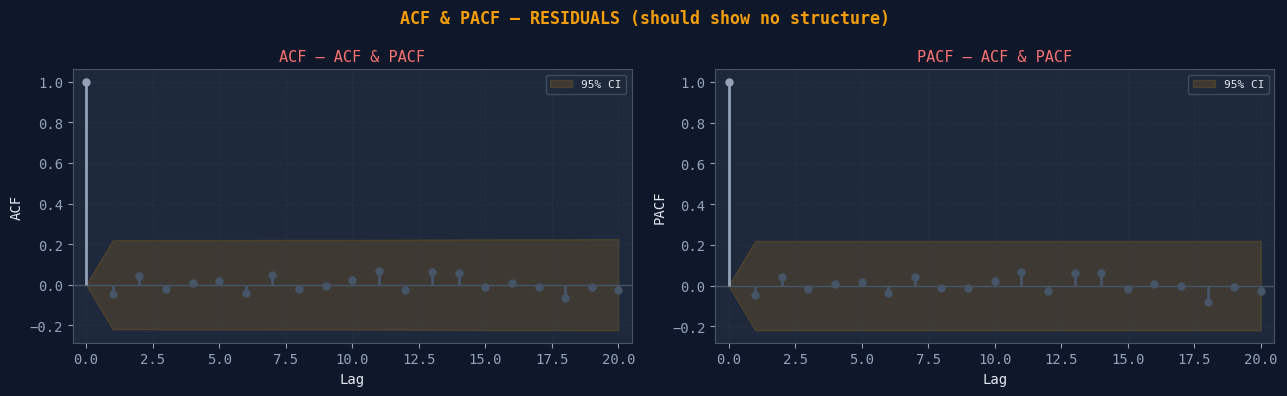

  ✓ Saved: 09_acf_pacf_residuals.png

  Ljung-Box Test (H₀: residuals are white noise):
     Lag      Q-stat     p-value                Result
  ────────────────────────────────────────────────────
       5      0.3944      0.9955         ✓ White Noise
      10      0.8112      0.9999         ✓ White Noise
      15      1.9963      1.0000         ✓ White Noise

  Shapiro-Wilk Normality Test:
    W=0.3278, p=0.0000  ✗ Non-normal

  SECTION 10: ARIMA(3,1,0) FULL MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   80
Model:                 ARIMA(3, 1, 0)   Log Likelihood                -202.280
Date:                Wed, 25 Feb 2026   AIC                            412.560
Time:                        21:14:33   BIC                            422.038
Sample:                             0   HQIC                           416.357
                                 - 80          

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 9 — DIAGNOSTIC PLOTS (Residuals)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 9: DIAGNOSTIC PLOTS — RESIDUAL ANALYSIS")
print("=" * 70)

residuals = final_model.resid

fig = plt.figure(figsize=(14, 10))
fig.suptitle('ARIMA(3,1,0) — DIAGNOSTIC PLOTS (In-Sample Residuals)',
             fontsize=13, color=AMBER, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# ── 1. Residuals over time ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(t_train, residuals, color=AMBER, lw=1.2, alpha=0.8)
ax1.axhline(0,   color=ROSE,  lw=1.5, ls='--')
ax1.axhline(+2*np.std(residuals), color='#475569', lw=1, ls=':', alpha=0.7,
            label='±2σ')
ax1.axhline(-2*np.std(residuals), color='#475569', lw=1, ls=':', alpha=0.7)
ax1.fill_between(t_train,
                  -2*np.std(residuals), 2*np.std(residuals),
                  alpha=0.08, color=AMBER)
ax1.set_xlabel('Time Index (t)')
ax1.set_ylabel('Residual εₜ')
ax1.set_title('Residuals over Time (should be random, centred at 0)', color=SLATE)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ── 2. Residual histogram + Normal overlay ────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(residuals, bins=15, color=BLUE, edgecolor='#334155',
         alpha=0.75, density=True, label='Residuals')
mu, std = residuals.mean(), residuals.std()
xr = np.linspace(mu - 4*std, mu + 4*std, 200)
ax2.plot(xr, stats.norm.pdf(xr, mu, std), color=AMBER, lw=2,
         label=f'Normal(μ={mu:.2f}, σ={std:.2f})')
ax2.set_xlabel('Residual value')
ax2.set_ylabel('Density')
ax2.set_title('Residual Distribution', color=SLATE)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ── 3. Q-Q Plot ────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
ax3.scatter(osm, osr, color=BLUE, s=20, alpha=0.8, zorder=3,
            label='Sample quantiles')
ax3.plot(osm, slope*np.array(osm)+intercept, color=ROSE, lw=2,
         label='Normal line')
ax3.set_xlabel('Theoretical Quantiles')
ax3.set_ylabel('Sample Quantiles')
ax3.set_title('Q-Q Plot (Normal)', color=SLATE)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.savefig('08_diagnostics.png', dpi=150, bbox_inches='tight',
            facecolor='#0f172a')
plt.show()
print("  ✓ Saved: 08_diagnostics.png")

# ── ACF/PACF of residuals ──────────────────────────────────────────────────
plot_acf_pacf(residuals, 'ACF & PACF — RESIDUALS (should show no structure)',
              '09_acf_pacf_residuals.png', color=ROSE)

# ── Ljung-Box test ─────────────────────────────────────────────────────────
lb_result = acorr_ljungbox(residuals, lags=[5, 10, 15], return_df=True)
print(f"\n  Ljung-Box Test (H₀: residuals are white noise):")
print(f"  {'Lag':>6}  {'Q-stat':>10}  {'p-value':>10}  {'Result':>20}")
print("  " + "─" * 52)
for lag, row in lb_result.iterrows():
    result_str = '✓ White Noise' if row['lb_pvalue'] > 0.05 else '✗ Autocorrelated'
    print(f"  {int(lag):>6}  {row['lb_stat']:>10.4f}  {row['lb_pvalue']:>10.4f}  {result_str:>20}")

# Normality test
stat, p_norm = stats.shapiro(residuals)
print(f"\n  Shapiro-Wilk Normality Test:")
print(f"    W={stat:.4f}, p={p_norm:.4f}  "
      f"{'✓ Normally distributed' if p_norm > 0.05 else '✗ Non-normal'}")

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 10 — MODEL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 10: ARIMA(3,1,0) FULL MODEL SUMMARY")
print("=" * 70)
print(final_model.summary())